In [1]:
import pandas as pd

import numpy as np 

import matplotlib.pyplot as plt 

import seaborn as sns 

In [2]:
df = pd.read_csv("data/retail_store_sales.csv")

df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [3]:
df .shape 

(12575, 11)

In [4]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [6]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [7]:
df.describe(include='object')

,Transaction ID,Customer ID,Category,Item,Payment Method,Location,Transaction Date,Discount Applied
count,12575,12575,12575,11362,12575,12575,12575,8376
unique,12575,25,8,200,3,2,1114,2
top,TXN_6867343,CUST_05,Furniture,Item_2_BEV,Cash,Online,2022-05-30,True
freq,1,544,1591,126,4310,6354,26,4219


In [8]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [9]:
df[df["Item"].isnull()].head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
11,TXN_5422631,CUST_09,Milk Products,NaN,NaN,8.0,52.0,Digital Wallet,In-store,2025-01-12,True
15,TXN_1809665,CUST_14,Beverages,NaN,24.5,NaN,NaN,Credit Card,In-store,2022-05-11,NaN
17,TXN_9634894,CUST_15,Milk Products,NaN,NaN,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN
19,TXN_4206593,CUST_01,Furniture,NaN,35.0,NaN,NaN,Digital Wallet,Online,2025-01-13,False
21,TXN_8685338,CUST_15,Milk Products,NaN,NaN,3.0,105.0,Credit Card,In-store,2023-10-29,NaN
25,TXN_3481599,CUST_05,Furniture,NaN,39.5,NaN,NaN,Cash,Online,2022-09-08,False
32,TXN_1543244,CUST_20,Food,NaN,NaN,8.0,196.0,Credit Card,Online,2024-10-25,True
34,TXN_1621497,CUST_06,Patisserie,NaN,23.0,NaN,NaN,Cash,In-store,2023-02-18,NaN


In [10]:
df["Item"] = df["Item"].fillna("Unknown")

In [11]:
df["Item"].isnull().sum()

np.int64(0)

In [12]:
df[df["Item"] == "Unknown"].head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
5,TXN_7482416,CUST_09,Patisserie,Unknown,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
7,TXN_1372952,CUST_21,Furniture,Unknown,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
11,TXN_5422631,CUST_09,Milk Products,Unknown,NaN,8.0,52.0,Digital Wallet,In-store,2025-01-12,True
15,TXN_1809665,CUST_14,Beverages,Unknown,24.5,NaN,NaN,Credit Card,In-store,2022-05-11,NaN
17,TXN_9634894,CUST_15,Milk Products,Unknown,NaN,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN
19,TXN_4206593,CUST_01,Furniture,Unknown,35.0,NaN,NaN,Digital Wallet,Online,2025-01-13,False
21,TXN_8685338,CUST_15,Milk Products,Unknown,NaN,3.0,105.0,Credit Card,In-store,2023-10-29,NaN
25,TXN_3481599,CUST_05,Furniture,Unknown,39.5,NaN,NaN,Cash,Online,2022-09-08,False
32,TXN_1543244,CUST_20,Food,Unknown,NaN,8.0,196.0,Credit Card,Online,2024-10-25,True
34,TXN_1621497,CUST_06,Patisserie,Unknown,23.0,NaN,NaN,Cash,In-store,2023-02-18,NaN


In [13]:
df[df["Price Per Unit"].isnull()].head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
5,TXN_7482416,CUST_09,Patisserie,Unknown,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
11,TXN_5422631,CUST_09,Milk Products,Unknown,NaN,8.0,52.0,Digital Wallet,In-store,2025-01-12,True
17,TXN_9634894,CUST_15,Milk Products,Unknown,NaN,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN
21,TXN_8685338,CUST_15,Milk Products,Unknown,NaN,3.0,105.0,Credit Card,In-store,2023-10-29,NaN
32,TXN_1543244,CUST_20,Food,Unknown,NaN,8.0,196.0,Credit Card,Online,2024-10-25,True
127,TXN_4608122,CUST_21,Butchers,Unknown,NaN,10.0,275.0,Digital Wallet,Online,2022-10-01,False
159,TXN_3822751,CUST_21,Butchers,Unknown,NaN,9.0,126.0,Digital Wallet,In-store,2024-03-04,False
216,TXN_7804271,CUST_22,Patisserie,Unknown,NaN,8.0,40.0,Cash,Online,2023-02-10,NaN
247,TXN_3433195,CUST_24,Electric household essentials,Unknown,NaN,7.0,150.5,Cash,Online,2023-03-30,NaN
271,TXN_7571093,CUST_17,Milk Products,Unknown,NaN,9.0,99.0,Digital Wallet,In-store,2022-11-18,NaN


In [14]:
price_missing = (
    df["Price Per Unit"].isnull()
    & df["Quantity"].notnull()
    & df["Total Spent"].notnull()
)

In [15]:
df.loc[price_missing, "Price Per Unit"] = (
    df.loc[price_missing, "Total Spent"]
    / df.loc[price_missing, "Quantity"]
)

In [16]:
df["Price Per Unit"].isnull().sum()

np.int64(0)

In [17]:
df[df["Quantity"].isnull()].head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
7,TXN_1372952,CUST_21,Furniture,Unknown,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
15,TXN_1809665,CUST_14,Beverages,Unknown,24.5,NaN,NaN,Credit Card,In-store,2022-05-11,NaN
19,TXN_4206593,CUST_01,Furniture,Unknown,35.0,NaN,NaN,Digital Wallet,Online,2025-01-13,False
25,TXN_3481599,CUST_05,Furniture,Unknown,39.5,NaN,NaN,Cash,Online,2022-09-08,False
34,TXN_1621497,CUST_06,Patisserie,Unknown,23.0,NaN,NaN,Cash,In-store,2023-02-18,NaN
83,TXN_4532214,CUST_25,Patisserie,Unknown,15.5,NaN,NaN,Credit Card,In-store,2024-03-25,False
112,TXN_5419965,CUST_23,Computers and electric accessories,Unknown,20.0,NaN,NaN,Digital Wallet,Online,2024-01-16,False
114,TXN_8210621,CUST_03,Beverages,Unknown,39.5,NaN,NaN,Digital Wallet,Online,2024-01-03,False
118,TXN_8586300,CUST_11,Computers and electric accessories,Unknown,27.5,NaN,NaN,Credit Card,Online,2022-02-08,False
138,TXN_1154680,CUST_25,Furniture,Unknown,35.0,NaN,NaN,Credit Card,Online,2022-12-18,False


In [18]:
quantity_missing = (
    df["Quantity"].isnull()
    & df["Price Per Unit"].notnull()
    & df["Total Spent"].notnull()
)

In [19]:
df.loc[quantity_missing, "Quantity"] = (
    df.loc[quantity_missing, "Total Spent"]
    / df.loc[quantity_missing, "Price Per Unit"]
)

In [20]:
df["Quantity"].isnull().sum()

np.int64(604)

In [21]:
df[df["Quantity"].isnull()][
    ["Price Per Unit", "Quantity", "Total Spent"]
].isnull().sum()

Price Per Unit      0
Quantity          604
Total Spent       604
dtype: int64

In [22]:
df["Quantity"].median()

6.0

In [23]:
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())

In [24]:
df["Quantity"].isnull().sum()

np.int64(0)

In [25]:
df["Total Spent"].isnull().sum()

np.int64(604)

In [26]:
df[df["Total Spent"].isnull()].head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
7,TXN_1372952,CUST_21,Furniture,Unknown,33.5,6.0,NaN,Digital Wallet,In-store,2024-04-02,True
15,TXN_1809665,CUST_14,Beverages,Unknown,24.5,6.0,NaN,Credit Card,In-store,2022-05-11,NaN
19,TXN_4206593,CUST_01,Furniture,Unknown,35.0,6.0,NaN,Digital Wallet,Online,2025-01-13,False
25,TXN_3481599,CUST_05,Furniture,Unknown,39.5,6.0,NaN,Cash,Online,2022-09-08,False
34,TXN_1621497,CUST_06,Patisserie,Unknown,23.0,6.0,NaN,Cash,In-store,2023-02-18,NaN
83,TXN_4532214,CUST_25,Patisserie,Unknown,15.5,6.0,NaN,Credit Card,In-store,2024-03-25,False
112,TXN_5419965,CUST_23,Computers and electric accessories,Unknown,20.0,6.0,NaN,Digital Wallet,Online,2024-01-16,False
114,TXN_8210621,CUST_03,Beverages,Unknown,39.5,6.0,NaN,Digital Wallet,Online,2024-01-03,False
118,TXN_8586300,CUST_11,Computers and electric accessories,Unknown,27.5,6.0,NaN,Credit Card,Online,2022-02-08,False
138,TXN_1154680,CUST_25,Furniture,Unknown,35.0,6.0,NaN,Credit Card,Online,2022-12-18,False


In [27]:
df[df["Total Spent"].isnull()][
    ["Price Per Unit", "Quantity", "Total Spent"]
].head(10)

,Price Per Unit,Quantity,Total Spent
7,33.5,6.0,NaN
15,24.5,6.0,NaN
19,35.0,6.0,NaN
25,39.5,6.0,NaN
34,23.0,6.0,NaN
83,15.5,6.0,NaN
112,20.0,6.0,NaN
114,39.5,6.0,NaN
118,27.5,6.0,NaN
138,35.0,6.0,NaN


In [28]:
df["Total Spent"] = df["Total Spent"].fillna(
    df["Price Per Unit"] * df["Quantity"]
)

In [29]:
df["Total Spent"].isnull().sum()

np.int64(0)

In [30]:
df['Discount Applied'].value_counts(dropna=False)

Discount Applied
True     4219
NaN      4199
False    4157
Name: count, dtype: int64

In [31]:
df['Discount Applied'].isna().sum()

np.int64(4199)

In [32]:
df['Discount Applied'].isna().mean() * 100

np.float64(33.39165009940358)

In [33]:
df['Discount Applied'].unique()

array([True, False, nan], dtype=object)

In [34]:
df['Discount Applied'].fillna('No')

0         True
1         True
2        False
3           No
4        False
         ...  
12570       No
12571    False
12572       No
12573     True
12574       No
Name: Discount Applied, Length: 12575, dtype: object

In [35]:
df['Discount Applied'].value_counts(dropna=False)
df['Discount Applied'].isna().sum()
df['Discount Applied'].unique()

array([True, False, nan], dtype=object)

In [36]:
df['Discount Applied'].value_counts(dropna=False)

Discount Applied
True     4219
NaN      4199
False    4157
Name: count, dtype: int64

In [37]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')

In [38]:
df[df['Discount Applied'].isna()].head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
5,TXN_7482416,CUST_09,Patisserie,Unknown,20.0,10.0,200.0,Credit Card,Online,2023-11-30,NaN
14,TXN_2490363,CUST_09,Milk Products,Item_16_MILK,27.5,2.0,55.0,Digital Wallet,Online,2022-05-22,NaN
15,TXN_1809665,CUST_14,Beverages,Unknown,24.5,6.0,147.0,Credit Card,In-store,2022-05-11,NaN
17,TXN_9634894,CUST_15,Milk Products,Unknown,27.5,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN


In [39]:
df[df['Discount Applied'].isna()]['Total Spent'].describe()

count    4199.000000
mean      128.856990
std        94.167496
min         5.000000
25%        50.000000
50%       107.500000
75%       192.000000
max       410.000000
Name: Total Spent, dtype: float64

In [40]:
df.groupby('Discount Applied')['Total Spent'].describe()

,count,mean,std,min,25%,50%,75%,max
Discount Applied,,,,,,,,
False,4157.0,130.796728,92.272587,5.0,55.5,111.0,192.0,410.0
True,4219.0,130.972861,94.279552,5.0,52.0,110.0,192.5,410.0


In [41]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.dtypes

Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object

In [44]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [45]:
df['Transaction Date'].dtype

dtype('<M8[ns]')

In [46]:
df['Discount Applied'] = df['Discount Applied'].astype('boolean')

In [47]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

df['Discount Applied'] = df['Discount Applied'].astype('boolean')

In [48]:
df.dtypes

Transaction ID              object
Customer ID                 object
Category                    object
Item                        object
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Discount Applied           boolean
dtype: object

In [49]:
df['Quantity'].unique()

array([10.,  9.,  2.,  7.,  8.,  6.,  1.,  3.,  4.,  5.])

In [50]:
df['Quantity'].isna().sum()

np.int64(0)

In [51]:
df['Quantity'].describe()

count    12575.000000
mean         5.558648
std          2.790160
min          1.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         10.000000
Name: Quantity, dtype: float64

In [52]:
df['Quantity'] = df['Quantity'].astype(int)

In [53]:
df['Quantity'].dtype

dtype('int64')

In [54]:
df['Price Per Unit'].describe()

count    12575.000000
mean        23.369304
std         10.748728
min          5.000000
25%         14.000000
50%         23.000000
75%         33.500000
max         41.000000
Name: Price Per Unit, dtype: float64

In [55]:
Q1 = df['Price Per Unit'].quantile(0.25)
Q3 = df['Price Per Unit'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)

Lower bound: -15.25
Upper bound: 62.75


In [56]:
df[(df['Price Per Unit'] < lower) | (df['Price Per Unit'] > upper)].shape

(0, 11)

In [57]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)

Lower bound: -4.5
Upper bound: 15.5


In [58]:
df[(df['Quantity'] < lower) | (df['Quantity'] > upper)].shape

(0, 11)

In [59]:
df['Total Spent'].describe()

count    12575.000000
mean       130.208111
std         93.580667
min          5.000000
25%         52.000000
50%        110.000000
75%        192.000000
max        410.000000
Name: Total Spent, dtype: float64

In [60]:
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)

Lower bound: -158.0
Upper bound: 402.0


In [61]:
df[(df['Total Spent'] < lower) | (df['Total Spent'] > upper)].shape

(60, 11)

In [62]:
df['Calculated Total'] = df['Price Per Unit'] * df['Quantity']

In [63]:
df[df['Total Spent'] != df['Calculated Total']].shape

(0, 12)

In [64]:
df[['Price Per Unit', 'Quantity', 'Total Spent', 'Calculated Total']].head(10)

,Price Per Unit,Quantity,Total Spent,Calculated Total
0,18.5,10,185.0,185.0
1,29.0,9,261.0,261.0
2,21.5,2,43.0,43.0
3,27.5,9,247.5,247.5
4,12.5,7,87.5,87.5
5,20.0,10,200.0,200.0
6,5.0,8,40.0,40.0
7,33.5,6,201.0,201.0
8,27.5,1,27.5,27.5
9,36.5,3,109.5,109.5


In [65]:
df.drop(columns='Calculated Total', inplace=True)

In [66]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')

In [67]:
df['Category'].value_counts()

Category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

In [68]:
df['Payment Method'].value_counts(dropna=False)

Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64

In [69]:
df['Location'].value_counts(dropna=False)

Location
Online      6354
In-store    6221
Name: count, dtype: int64

In [70]:
df['Item'].value_counts(dropna=False)

Item
Unknown        1213
Item_2_BEV      126
Item_25_FUR     113
Item_11_FUR     110
Item_1_MILK     109
               ... 
Item_5_BEV        7
Item_13_FUR       7
Item_24_CEA       7
Item_21_PAT       6
Item_3_EHE        5
Name: count, Length: 201, dtype: int64

In [71]:
pd.crosstab(df['Category'], df['Item'].eq('Unknown'))

Item,False,True
Category,,
Beverages,1427,140
Butchers,1421,147
Computers and electric accessories,1397,161
Electric household essentials,1437,154
Food,1426,162
Furniture,1460,131
Milk Products,1425,159
Patisserie,1369,159


In [72]:
df[df['Item'] == 'Unknown']['Category'].value_counts()

Category
Food                                  162
Computers and electric accessories    161
Patisserie                            159
Milk Products                         159
Electric household essentials         154
Butchers                              147
Beverages                             140
Furniture                             131
Name: count, dtype: int64

In [73]:
df['Transaction Date'].isna().sum()

np.int64(0)

In [74]:
df['Transaction Date'].min()

Timestamp('2022-01-01 00:00:00')

In [75]:
df['Transaction Date'].max()

Timestamp('2025-01-18 00:00:00')

In [76]:
df[['Transaction ID', 'Customer ID']].isna().sum()

Transaction ID    0
Customer ID       0
dtype: int64

In [77]:
df['Transaction ID'].nunique()

12575

In [78]:
df['Customer ID'].nunique()

25

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              12575 non-null  object        
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  int64         
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  8376 non-null   boolean       
dtypes: boolean(1), datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 1007.1+ KB


In [80]:
df.describe()

,Price Per Unit,Quantity,Total Spent,Transaction Date
count,12575.000000,12575.000000,12575.000000,12575
mean,23.369304,5.558648,130.208111,2023-07-12 20:23:41.105368064
min,5.000000,1.000000,5.000000,2022-01-01 00:00:00
25%,14.000000,3.000000,52.000000,2022-09-30 00:00:00
50%,23.000000,6.000000,110.000000,2023-07-13 00:00:00
75%,33.500000,8.000000,192.000000,2024-04-24 00:00:00
max,41.000000,10.000000,410.000000,2025-01-18 00:00:00
std,10.748728,2.790160,93.580667,NaN


In [81]:
total_sales = df['Total Spent'].sum()

print("Total Sales:", total_sales)

Total Sales: 1637367.0


In [82]:
average_transaction = df['Total Spent'].mean()

print("Average Transaction:", average_transaction)

Average Transaction: 130.20811133200795


In [83]:
total_transactions = df['Transaction ID'].nunique()

print("Total Transactions:", total_transactions)

Total Transactions: 12575


In [84]:
total_customers = df['Customer ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 25


In [85]:
total_quantity = df['Quantity'].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 69900


In [86]:
category_sales = (
    df.groupby('Category')['Total Spent']
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Butchers                              218153.0
Electric household essentials         215297.5
Beverages                             206854.5
Furniture                             205390.0
Food                                  205225.0
Computers and electric accessories    202023.5
Patisserie                            194531.5
Milk Products                         189892.0
Name: Total Spent, dtype: float64

<Axes: title={'center': 'Total Sales by Category'}, xlabel='Category'>

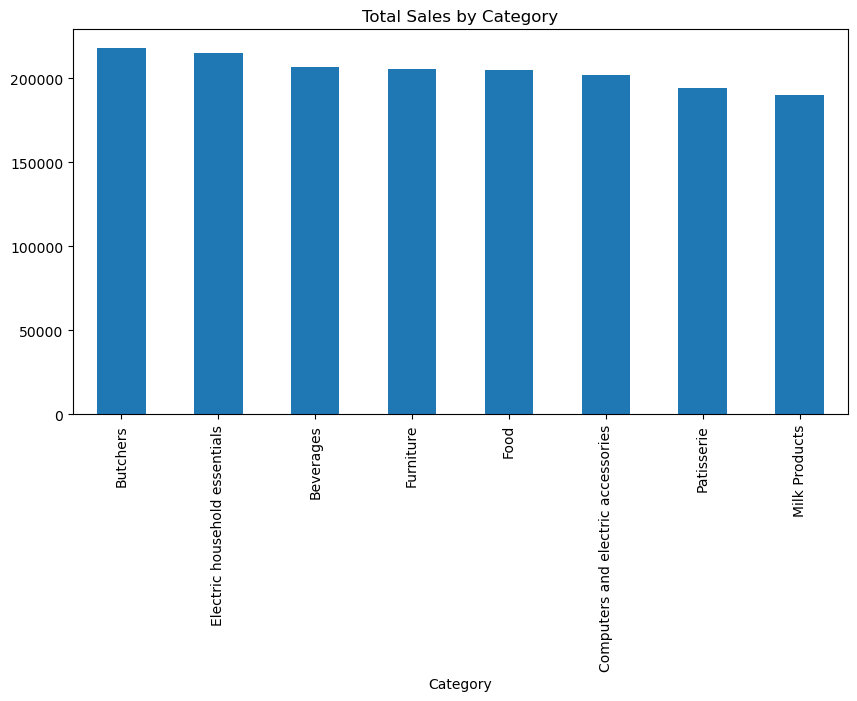

In [87]:
category_sales.plot(
    kind='bar',
    figsize=(10, 5),
    title='Total Sales by Category'
)

In [88]:
category_transactions = df['Category'].value_counts()

category_transactions

Category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

<Axes: title={'center': 'Number of Transactions by Category'}, xlabel='Category'>

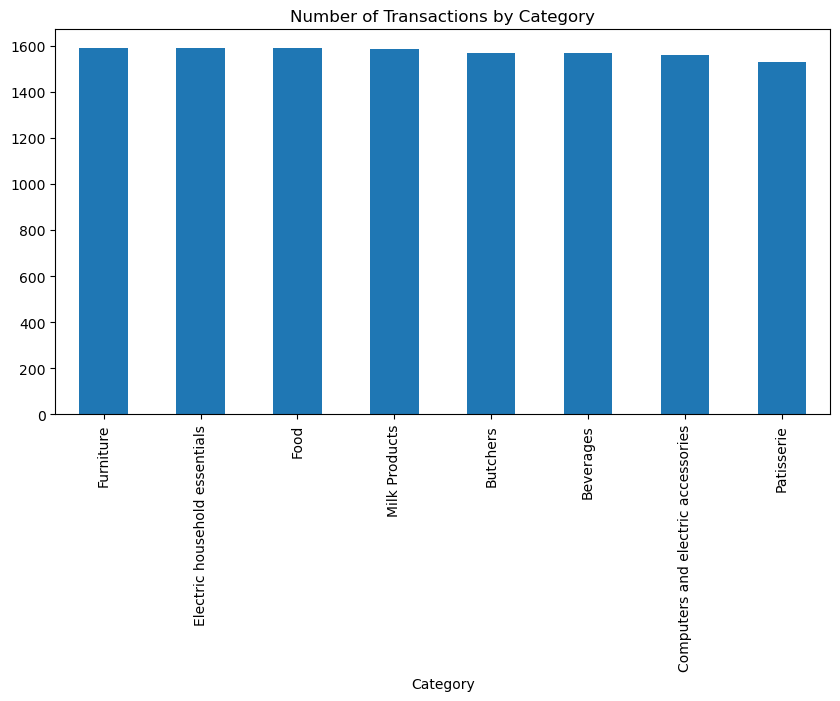

In [89]:
category_transactions.plot(
    kind='bar',
    figsize=(10, 5),
    title='Number of Transactions by Category'
)

In [90]:
category_avg_spending = (
    df.groupby('Category')['Total Spent']
      .mean()
      .sort_values(ascending=False)
)

category_avg_spending

Category
Butchers                              139.128189
Electric household essentials         135.322124
Beverages                             132.006701
Computers and electric accessories    129.668485
Food                                  129.234887
Furniture                             129.094909
Patisserie                            127.311191
Milk Products                         119.881313
Name: Total Spent, dtype: float64

<Axes: title={'center': 'Average Transaction Value by Category'}, xlabel='Category'>

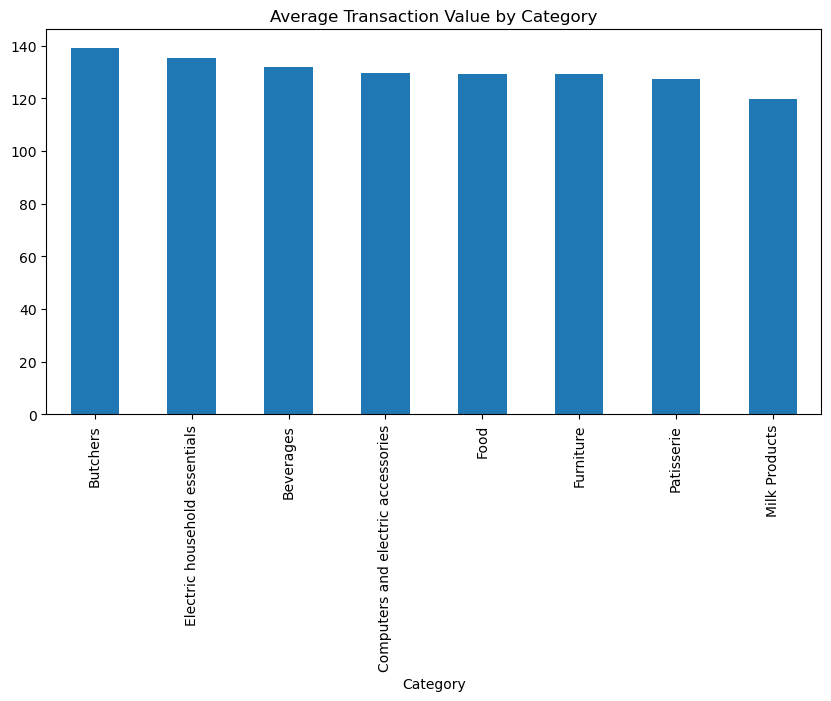

In [91]:
category_avg_spending.plot(
    kind='bar',
    figsize=(10, 5),
    title='Average Transaction Value by Category'
)

In [92]:
item_sales = (
    df.groupby('Item')['Total Spent']
      .sum()
      .sort_values(ascending=False)
)

item_sales.head(10)

Item
Unknown         164368.5
Item_25_FUR      25256.0
Item_25_EHE      23083.0
Item_25_BUT      21894.0
Item_24_FUR      21172.0
Item_25_FOOD     20541.0
Item_22_BUT      19710.0
Item_23_BUT      19114.0
Item_20_BUT      18860.5
Item_19_MILK     18848.0
Name: Total Spent, dtype: float64

<Axes: title={'center': 'Top 10 Items by Total Sales'}, ylabel='Item'>

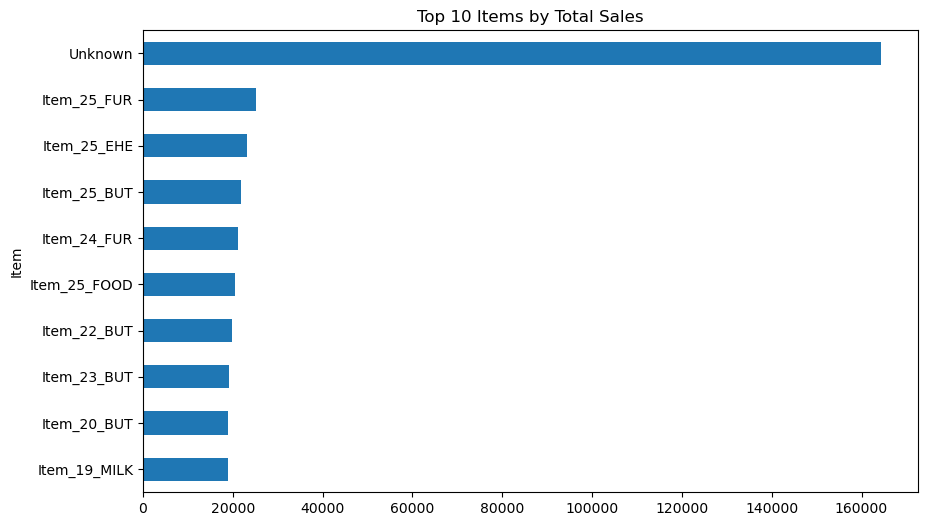

In [93]:
item_sales.head(10).sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top 10 Items by Total Sales'
)

In [94]:
item_quantity = (
    df.groupby('Item')['Quantity']
      .sum()
      .sort_values(ascending=False)
)

item_quantity.head(10)

Item
Unknown         7011
Item_2_BEV       676
Item_16_MILK     627
Item_25_FUR      616
Item_19_MILK     589
Item_13_FOOD     581
Item_5_FUR       581
Item_1_MILK      578
Item_11_MILK     574
Item_11_FUR      573
Name: Quantity, dtype: int64

<Axes: title={'center': 'Top 10 Items by Quantity Sold'}, ylabel='Item'>

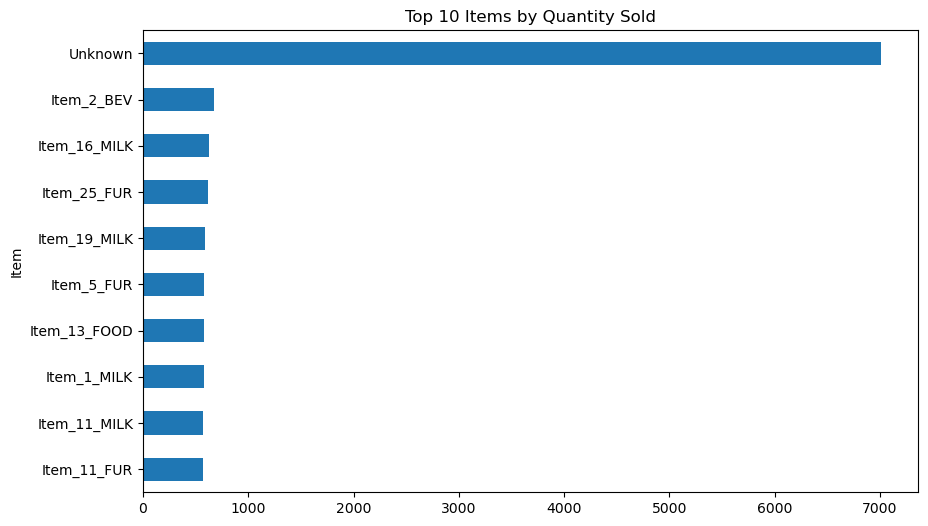

In [95]:
item_quantity.head(10).sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top 10 Items by Quantity Sold'
)

In [96]:
payment_transactions = df['Payment Method'].value_counts()

payment_transactions

Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64

<Axes: title={'center': 'Transactions by Payment Method'}, xlabel='Payment Method'>

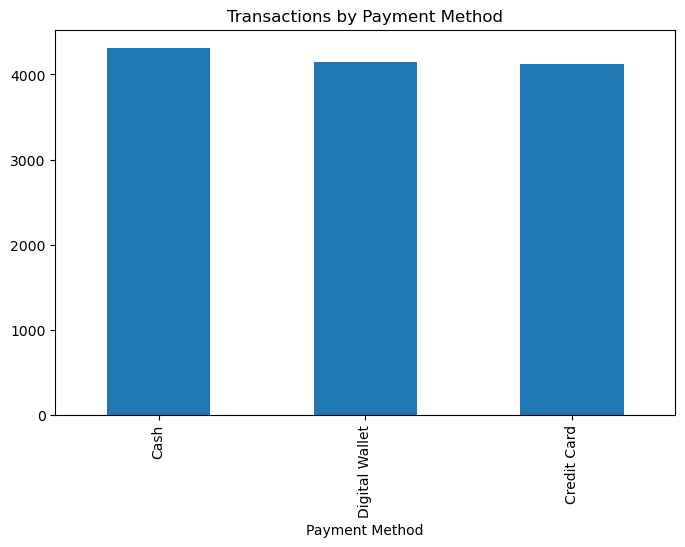

In [97]:
payment_transactions.plot(
    kind='bar',
    figsize=(8, 5),
    title='Transactions by Payment Method'
)

In [98]:
payment_sales = (
    df.groupby('Payment Method')['Total Spent']
      .sum()
      .sort_values(ascending=False)
)

payment_sales

Payment Method
Cash              567275.0
Digital Wallet    535617.0
Credit Card       534475.0
Name: Total Spent, dtype: float64

In [99]:
location_transactions = df['Location'].value_counts()

location_transactions

Location
Online      6354
In-store    6221
Name: count, dtype: int64

In [100]:
location_sales = (
    df.groupby('Location')['Total Spent']
      .sum()
      .sort_values(ascending=False)
)

location_sales

Location
Online      831922.0
In-store    805445.0
Name: Total Spent, dtype: float64

In [101]:
location_average = (
    df.groupby('Location')['Total Spent']
      .mean()
      .sort_values(ascending=False)
)

location_average

Location
Online      130.928864
In-store    129.471950
Name: Total Spent, dtype: float64

In [102]:
df['Year'] = df['Transaction Date'].dt.year

In [103]:
yearly_sales = (
    df.groupby('Year')['Total Spent']
      .sum()
)

yearly_sales

Year
2022    540602.5
2023    515501.0
2024    554296.0
2025     26967.5
Name: Total Spent, dtype: float64

<Axes: title={'center': 'Total Sales by Year'}, xlabel='Year'>

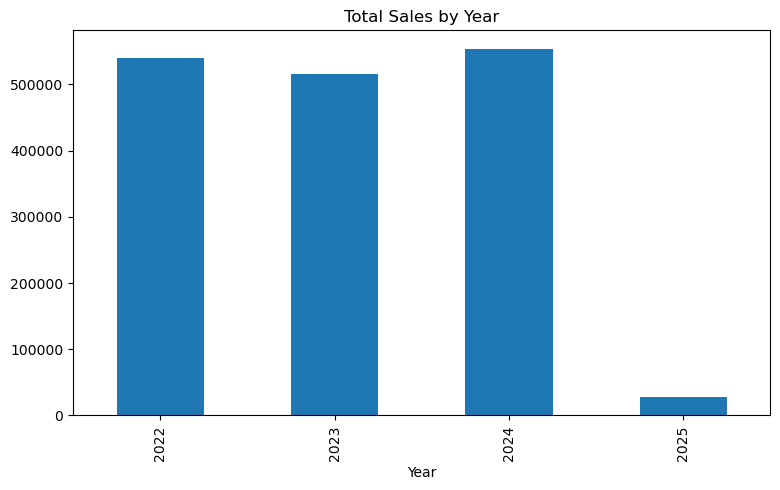

In [104]:
yearly_sales.plot(
    kind='bar',
    figsize=(9, 5),
    title='Total Sales by Year'
)

In [105]:
df['Month'] = df['Transaction Date'].dt.month

In [106]:
monthly_sales = (
    df.groupby('Month')['Total Spent']
      .sum()
)

monthly_sales

Month
1     183637.0
2     127662.0
3     129844.0
4     132164.5
5     132076.5
6     135906.0
7     138364.0
8     129656.5
9     134522.0
10    125827.5
11    130101.5
12    137605.5
Name: Total Spent, dtype: float64

<Axes: title={'center': 'Monthly Sales'}, xlabel='Month'>

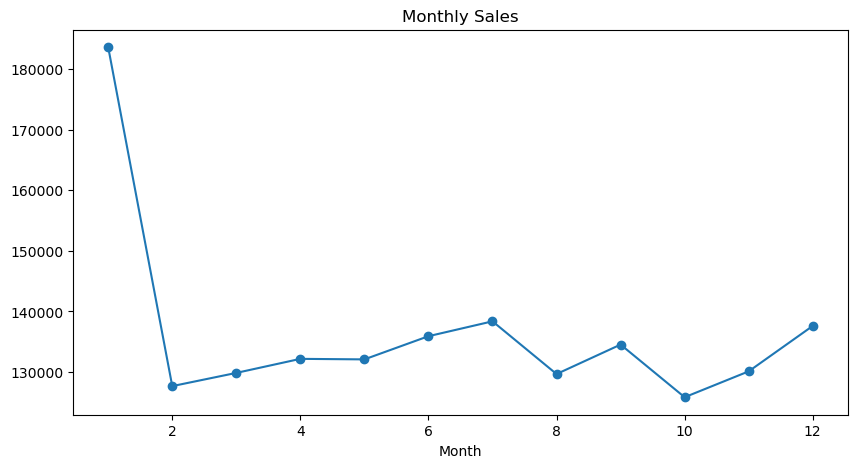

In [107]:
monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10, 5),
    title='Monthly Sales'
)

In [108]:
df['Year_Month'] = df['Transaction Date'].dt.to_period('M')

In [109]:
monthly_trend = (
    df.groupby('Year_Month')['Total Spent']
      .sum()
)

monthly_trend

Year_Month
2022-01    56271.5
2022-02    46268.5
2022-03    43225.0
2022-04    42584.0
2022-05    42066.5
2022-06    44481.0
2022-07    47453.5
2022-08    43415.5
2022-09    47541.5
2022-10    40422.0
2022-11    45366.5
2022-12    41507.0
2023-01    49354.5
2023-02    41392.5
2023-03    41405.5
2023-04    41056.5
2023-05    42490.5
2023-06    44061.0
2023-07    48191.5
2023-08    40080.0
2023-09    43028.0
2023-10    40320.0
2023-11    38715.0
2023-12    45406.0
2024-01    51043.5
2024-02    40001.0
2024-03    45213.5
2024-04    48524.0
2024-05    47519.5
2024-06    47364.0
2024-07    42719.0
2024-08    46161.0
2024-09    43952.5
2024-10    45085.5
2024-11    46020.0
2024-12    50692.5
2025-01    26967.5
Freq: M, Name: Total Spent, dtype: float64

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Year_Month'>

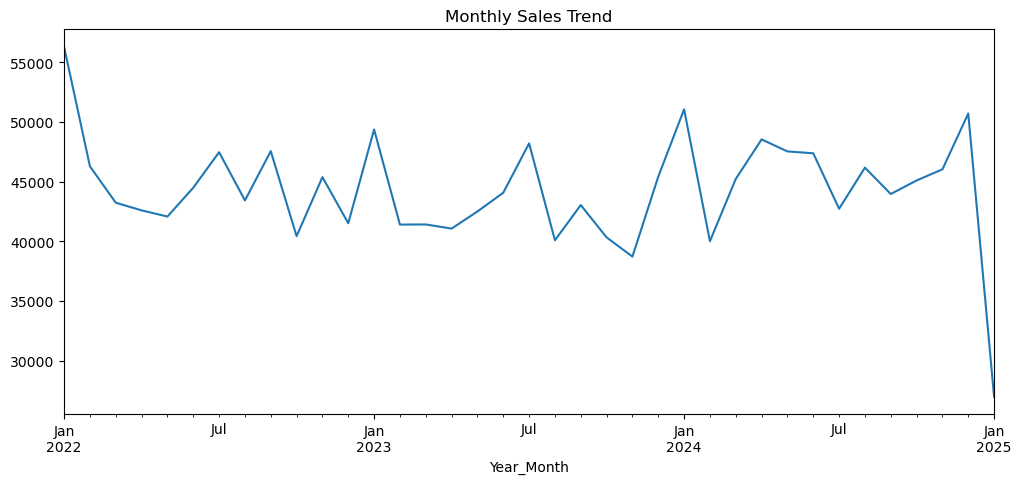

In [110]:
monthly_trend.plot(
    kind='line',
    figsize=(12, 5),
    title='Monthly Sales Trend'
)

In [111]:
customer_sales = (
    df.groupby('Customer ID')['Total Spent']
      .sum()
      .sort_values(ascending=False)
)

customer_sales.head(10)

Customer ID
CUST_24    71890.0
CUST_08    70822.5
CUST_05    70631.5
CUST_13    68904.0
CUST_23    68554.0
CUST_16    68225.5
CUST_10    66419.5
CUST_22    65980.5
CUST_15    65601.5
CUST_21    65366.0
Name: Total Spent, dtype: float64

In [112]:
customer_transactions = df['Customer ID'].value_counts()

customer_transactions.head(10)

Customer ID
CUST_05    544
CUST_24    543
CUST_13    534
CUST_08    533
CUST_09    519
CUST_15    519
CUST_16    515
CUST_23    513
CUST_20    507
CUST_18    507
Name: count, dtype: int64

In [113]:
discount_analysis = (
    df.dropna(subset=['Discount Applied'])
      .groupby('Discount Applied')['Total Spent']
      .agg(['count', 'sum', 'mean'])
)

discount_analysis

,count,sum,mean
Discount Applied,,,
False,4157,543722.0,130.796728
True,4219,552574.5,130.972861


In [114]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Year,Month,Year_Month
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True,2024,4,2024-04
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True,2023,7,2023-07
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Credit Card,Online,2022-10-05,False,2022,10,2022-10
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,Credit Card,Online,2022-05-07,<NA>,2022,5,2022-05
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Digital Wallet,Online,2022-10-02,False,2022,10,2022-10


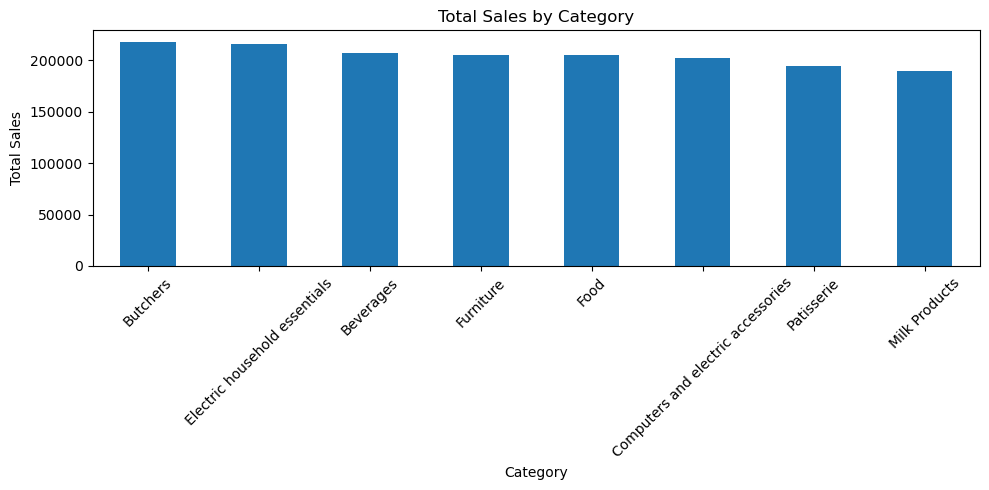

In [115]:
category_sales.plot(
    kind='bar',
    figsize=(10, 5),
    title='Total Sales by Category'
)

plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

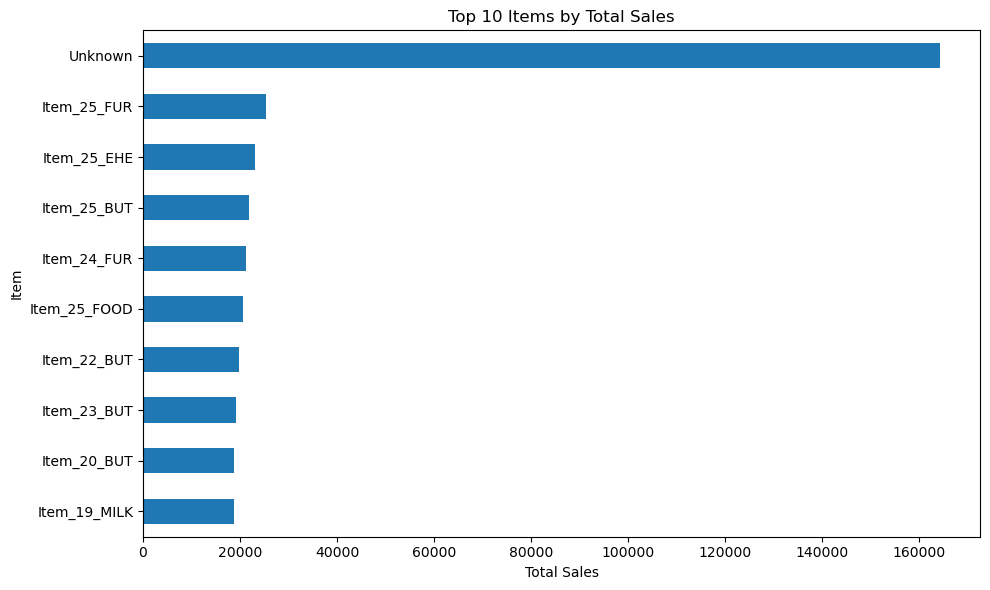

In [116]:
item_sales.head(10).sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top 10 Items by Total Sales'
)

plt.xlabel('Total Sales')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

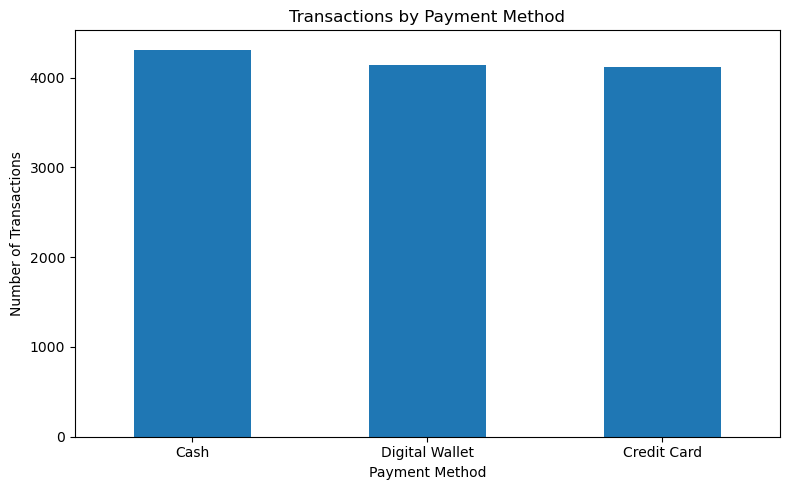

In [117]:
payment_transactions.plot(
    kind='bar',
    figsize=(8, 5),
    title='Transactions by Payment Method'
)

plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

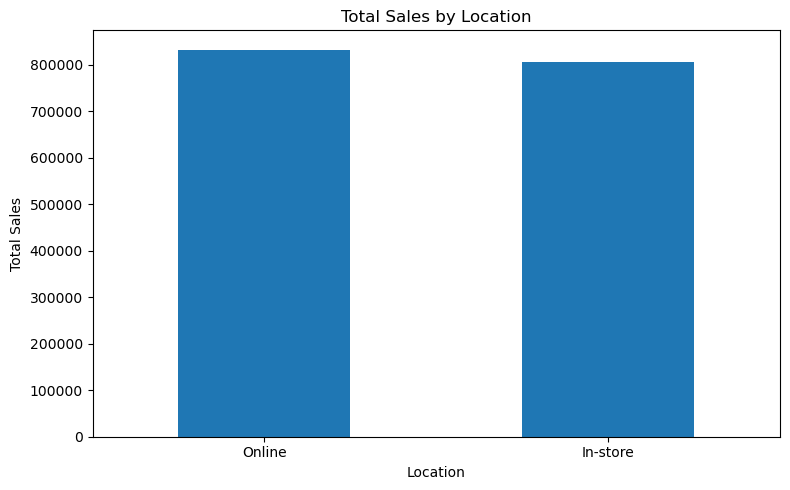

In [118]:
location_sales.plot(
    kind='bar',
    figsize=(8, 5),
    title='Total Sales by Location'
)

plt.xlabel('Location')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

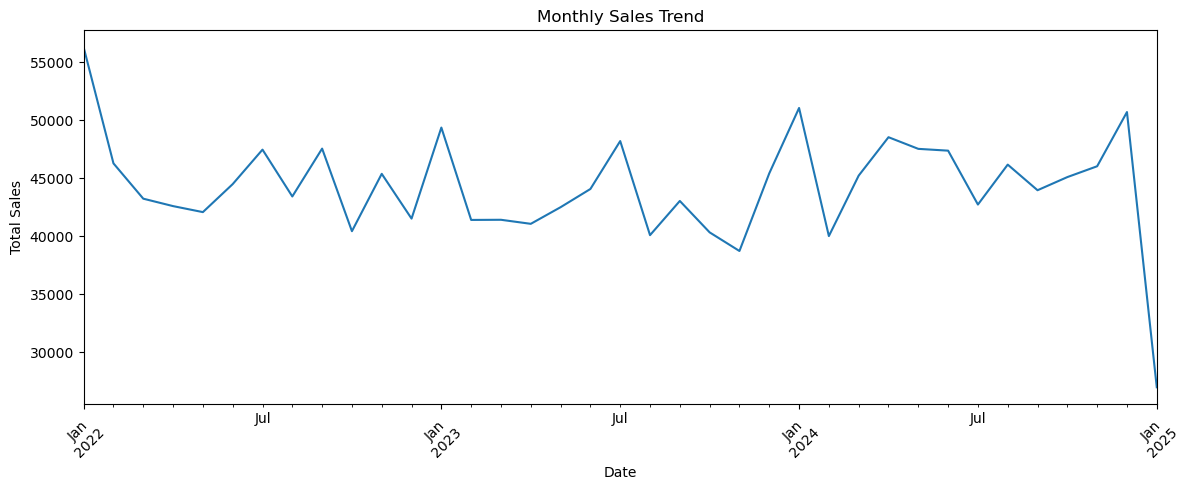

In [119]:
monthly_trend.plot(
    kind='line',
    figsize=(12, 5),
    title='Monthly Sales Trend'
)

plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

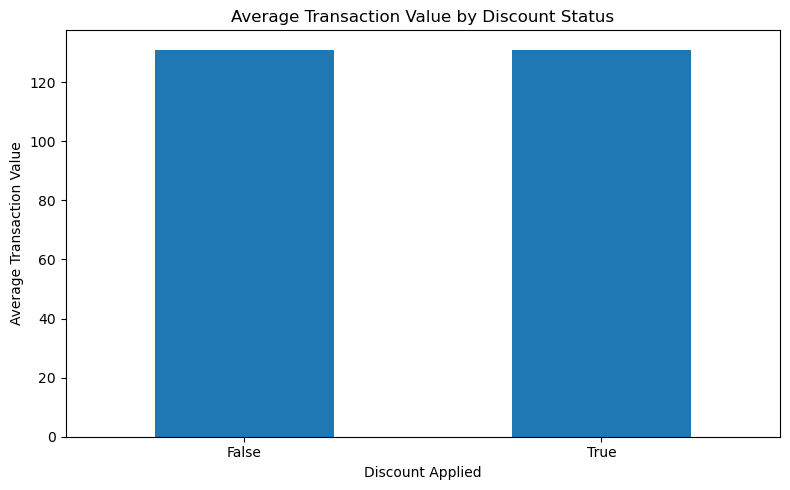

In [120]:
discount_analysis['mean'].plot(
    kind='bar',
    figsize=(8, 5),
    title='Average Transaction Value by Discount Status'
)

plt.xlabel('Discount Applied')
plt.ylabel('Average Transaction Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [121]:
top_category = category_sales.idxmax()
top_category_sales = category_sales.max()

print("Top Category:", top_category)
print("Sales:", top_category_sales)

Top Category: Butchers
Sales: 218153.0


In [122]:
top_item = item_sales.idxmax()
top_item_sales = item_sales.max()

print("Top Item:", top_item)
print("Sales:", top_item_sales)

Top Item: Unknown
Sales: 164368.5


In [123]:
known_item_sales = (
    df[df['Item'] != 'Unknown']
    .groupby('Item')['Total Spent']
    .sum()
    .sort_values(ascending=False)
)

known_item_sales.head(10)

Item
Item_25_FUR     25256.0
Item_25_EHE     23083.0
Item_25_BUT     21894.0
Item_24_FUR     21172.0
Item_25_FOOD    20541.0
Item_22_BUT     19710.0
Item_23_BUT     19114.0
Item_20_BUT     18860.5
Item_19_MILK    18848.0
Item_23_EHE     18468.0
Name: Total Spent, dtype: float64

In [124]:
top_known_item = known_item_sales.idxmax()
top_known_item_sales = known_item_sales.max()

print("Top Known Item:", top_known_item)
print("Sales:", top_known_item_sales)

Top Known Item: Item_25_FUR
Sales: 25256.0


In [125]:
top_location = location_sales.idxmax()
top_location_sales = location_sales.max()

print("Top Location:", top_location)
print("Sales:", top_location_sales)

Top Location: Online
Sales: 831922.0


In [126]:
top_payment = payment_transactions.idxmax()
top_payment_count = payment_transactions.max()

print("Most Used Payment Method:", top_payment)
print("Transactions:", top_payment_count)

Most Used Payment Method: Cash
Transactions: 4310


In [127]:
best_year = yearly_sales.idxmax()
best_year_sales = yearly_sales.max()

print("Best Year:", best_year)
print("Sales:", best_year_sales)

Best Year: 2024
Sales: 554296.0


In [128]:
discount_analysis = (
    df.dropna(subset=['Discount Applied'])
      .groupby('Discount Applied')['Total Spent']
      .agg(['count', 'sum', 'mean'])
)

discount_analysis

,count,sum,mean
Discount Applied,,,
False,4157,543722.0,130.796728
True,4219,552574.5,130.972861


In [129]:
discount_analysis

,count,sum,mean
Discount Applied,,,
False,4157,543722.0,130.796728
True,4219,552574.5,130.972861


In [130]:
discount_comparison = (
    df.dropna(subset=['Discount Applied'])
      .groupby('Discount Applied')['Total Spent']
      .mean()
)

discount_comparison

Discount Applied
False    130.796728
True     130.972861
Name: Total Spent, dtype: float64

In [131]:
print("Total Sales:", df['Total Spent'].sum())
print("Total Transactions:", df['Transaction ID'].nunique())
print("Total Customers:", df['Customer ID'].nunique())
print("Total Quantity Sold:", df['Quantity'].sum())

Total Sales: 1637367.0
Total Transactions: 12575
Total Customers: 25
Total Quantity Sold: 69900


In [132]:
category_sales.head(5)

Category
Butchers                         218153.0
Electric household essentials    215297.5
Beverages                        206854.5
Furniture                        205390.0
Food                             205225.0
Name: Total Spent, dtype: float64

In [133]:
lowest_category = category_sales.idxmin()
lowest_category_sales = category_sales.min()

print("Lowest Category:", lowest_category)
print("Sales:", lowest_category_sales)

Lowest Category: Milk Products
Sales: 189892.0


In [134]:
lowest_known_item = known_item_sales.idxmin()
lowest_known_item_sales = known_item_sales.min()

print("Lowest Known Item:", lowest_known_item)
print("Sales:", lowest_known_item_sales)

Lowest Known Item: Item_3_EHE
Sales: 224.0


In [135]:
df.shape

(12575, 14)

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              12575 non-null  object        
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  int64         
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  8376 non-null   boolean       
 11  Year              12575 non-null  int32         
 12  Month             12575 non-null  int32         
 13  Year_Month        12575 non-null  period[M]     
dtypes: boolean(1), datetim

In [137]:
df.isna().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
Year                   0
Month                  0
Year_Month             0
dtype: int64

In [138]:
df.duplicated().sum()

np.int64(0)

In [139]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Year,Month,Year_Month
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True,2024,4,2024-04
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True,2023,7,2023-07
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Credit Card,Online,2022-10-05,False,2022,10,2022-10
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,Credit Card,Online,2022-05-07,<NA>,2022,5,2022-05
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Digital Wallet,Online,2022-10-02,False,2022,10,2022-10


In [140]:
df.shape

(12575, 14)